### Energy efficiency policies
**Source** : Survey TREMI 2020  
https://www.statistiques.developpement-durable.gouv.fr

1. **What fraction of retrofits were supported by policies ?**
2. **What loan facilities households used most ?**
3. **How prevalent policy interactions were ?**

### 0. Imports and data

In [32]:
!pip install matplotlib
!pip install seaborn
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 97.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 69.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [linearmodels] [linearmodels]


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Econometric libraries
from linearmodels.iv import IV2SLS          # 2SLS estimator
import statsmodels.formula.api as smf       # OLS baseline
from statsmodels.stats.diagnostic import linear_reset


plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COLORS = plt.cm.tab10.colors

print('Libraries loaded.')

Libraries loaded.


In [4]:
DATA_PATH = 'data/raw/tremi_2020_metropole_opda.csv'
df = pd.read_csv(DATA_PATH, sep=None, engine='python')
print(f"Number of observations : {len(df):,}")
print(f"Number of variables   : {df.shape[1]}")

Number of observations : 51,689
Number of variables   : 386


In [5]:
# aid labels
AID_LABELS = {
    1:  'CITE (crédit d\'impôt)',
    2:  'Éco-PTZ',
    3:  'TVA réduite',
    4:  'CEE (certificats éco-énergie)',
    5:  'Subvention ANAH (Habiter Mieux)',
    16: 'Chèque Énergie National',
    6:  'Subventions locales (autres)',
    7:  'Pass Rénovation',
    17: 'AREL',
    8:  'Chèque éco-énergie régional',
    9:  'Éco-chèque Occitanie',
    10: 'AREEP Pays de la Loire',
    11: 'ENERGETIS',
    12: 'ARTÉÉ',
    13: 'Bordeaux Métropole Énergies',
    14: 'Provence éco-rénov',
    15: 'Effilogis Bourgogne-FC',
    22: 'Autre aide',
    23: 'Aucune aide',
}

# loan labels
LOAN_LABELS = {
    1: 'Éco-PTZ',
    2: 'Prêt immobilier bancaire',
    3: 'Crédit à la consommation',
    4: 'Autre type de prêt',
    5: 'Facilités de paiement fournisseur',
    6: 'Vente d\'une parcelle',
    7: 'Surélévation / extension',
    8: 'Héritage / donation',
    9: 'Fonds propres (autofinancement)',
}

# work types labels
WORK_LABELS = {
    11: 'Toiture avec isolation',
    12: 'Toiture sans isolation',
    13: 'Isolation toiture seule',
    14: 'Isolation plancher combles',
    15: 'Toiture-terrasse avec isolation',
    16: 'Toiture-terrasse sans isolation',
    21: 'Murs ext. avec isolation',
    22: 'Murs ext. sans isolation',
    23: 'Murs int. avec isolation',
    24: 'Murs int. sans isolation',
    31: 'Plancher bas avec isolation',
    32: 'Plancher bas sans isolation',
    41: 'Fenêtres / baies vitrées',
    42: 'Volets / jalousies',
    43: 'Portes extérieures',
    51: 'Système de chauffage',
    52: 'Régulation chauffage',
    53: 'Eau chaude sanitaire',
    54: 'Calorifugeage',
    55: 'Ventilation',
    56: 'Climatisation',
    57: 'Rafraîchissement hors clim.',
    58: 'Panneaux photovoltaïques',
}

# Direct energetic impact gestures (envelope + efficient systems)
ENERGY_GESTES = [11, 13, 14, 15, 21, 23, 31, 41, 51, 53, 54, 55, 58]

In [6]:
# column indicating if at least one work has been done between 2017-2019
q1_cols = [f'Q1_{i}' for i in range(1, 24)]

def has_work_type(row, code):
    """Returns True if the household has done the work type 'code'."""
    return any(row.get(c) == code for c in q1_cols)

# Boolean : has done at least 1 work (code != 97)
df['work_done'] = df[q1_cols].apply(
    lambda row: any((v not in [97, np.nan]) and pd.notna(v) for v in row), axis=1
)

# Sub-sample : long questionnaire (people who completed works in 2019)
df_long = df[df['Recode_Court_Long'] == 1].copy()

# Columns Q71 (used aids)
q71_cols = [f'Q71_{i}' for i in range(1, 9)]

# Columns Q74 (funding)
q74_cols = [f'Q74_{i}' for i in range(1, 10)]

# Columns Q72 (role of the aid)
q72_cols = [f'Q72_{i}' for i in range(1, 7)]

# Columns Q70 (knowledge of the aids)
q70_cols = [c for c in df.columns if c.startswith('Q70_')]

print(f"Household that have done works : {df['work_done'].sum()}")
print(f"Long questionnaire (works 2019) : {len(df_long)}")

Household that have done works : 21632
Long questionnaire (works 2019) : 10302


### 1. What fraction of retrofits were supported by policies ?
We use several indicators:
- **Q70**: knowledge of the schemes (awareness)
- **Q71**: actual use of one or more aids
- **Q72**: role of aid in the decision to carry out renovation works

#### 1.1 Overall rate of use of public aid

In [7]:
# Calculate the total amount of aid used per household
def get_aids_used(row):
    aids = set()
    for c in q71_cols:
        v = row.get(c)
        if pd.notna(v):
            try:
                aids.add(int(v))
            except:
                pass
    return aids

df_long['aids_set'] = df_long.apply(get_aids_used, axis=1)

# Has used at least one aid (≠ none, ≠ empty)
df_long['a_aide'] = df_long['aids_set'].apply(
    lambda s: len(s) > 0 and not (s == {23})
)
# No aid declared (code 23)
df_long['aucune_aide'] = df_long['aids_set'].apply(lambda s: 23 in s)

# Amount of aids used
df_long['n_aides'] = df_long['aids_set'].apply(
    lambda s: len(s - {23}) if s else 0
)

w = df_long['wCal']

pct_aid      = (df_long['a_aide'] * w).sum() / w.sum() * 100
pct_no_aid   = (df_long['aucune_aide'] * w).sum() / w.sum() * 100
pct_no_response = 100 - pct_aid - pct_no_aid

print(f"Share of the works with at least one public aid : {pct_aid:.1f}%")
print(f"Share of the works without any declared aid : {pct_no_aid:.1f}%")
print(f"Non-response / NC : {pct_no_response:.1f}%")

Share of the works with at least one public aid : 50.3%
Share of the works without any declared aid : 26.2%
Non-response / NC : 23.5%


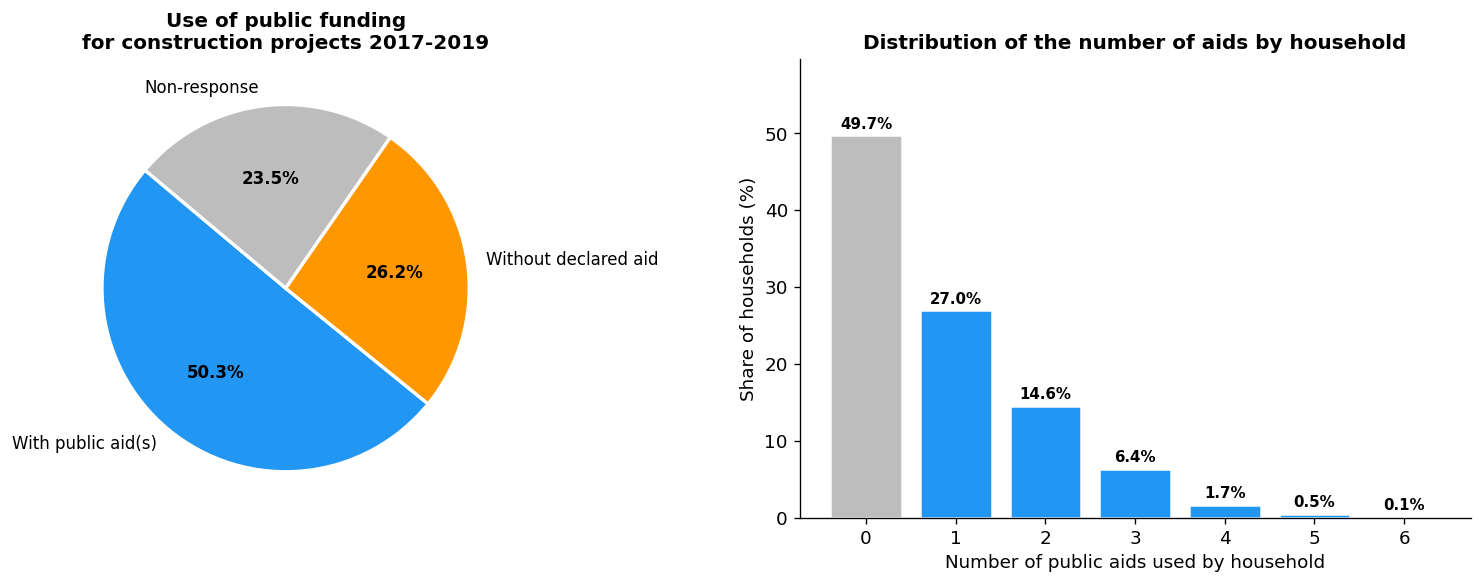

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
labels_pie = ['With public aid(s)', 'Without declared aid', 'Non-response']
sizes = [pct_aid, pct_no_aid, pct_no_response]
colors = ['#2196F3', '#FF9800', '#BDBDBD']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Use of public funding\nfor construction projects 2017-2019', fontsize=12, fontweight='bold')

ax2 = axes[1]
n_aid_dist = df_long.groupby('n_aides').apply(
    lambda g: g['wCal'].sum()
)
n_aid_pct = n_aid_dist / n_aid_dist.sum() * 100
n_aid_pct = n_aid_pct[n_aid_pct.index <= 6]  # tronquer à 6+

bars = ax2.bar(n_aid_pct.index.astype(str), n_aid_pct.values,
               color=['#BDBDBD'] + ['#2196F3'] * (len(n_aid_pct) - 1),
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, n_aid_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel("Number of public aids used by household", fontsize=11)
ax2.set_ylabel('Share of households (%)', fontsize=11)
ax2.set_title('Distribution of the number of aids by household', fontsize=12, fontweight='bold')
ax2.set_ylim(0, n_aid_pct.max() * 1.2)

plt.tight_layout()
plt.savefig('figures/fig1_taux_recours.png', bbox_inches='tight')
plt.show()

#### 1.2 Popularity of each aid type

* **CITE (Energy Transition Tax Credit):** A major national fiscal policy that allowed households to deduct a portion of their renovation costs (usually 30%) from their income tax. It was the most common aid for middle-income households before being replaced by "MaPrimeRénov'".
* **Éco-PTZ (Zero-Interest Eco-Loan):** A subsidized bank loan with a 0% interest rate. The government pays the interest to the bank on behalf of the household, helping them finance the "remaining out-of-pocket cost" of the renovation without extra debt charges.
* **Reduced VAT (5.5%):** An indirect subsidy where the standard VAT rate (20%) is lowered to 5.5% for energy improvement works. This reduction is applied directly to the professional's invoice, making it a very accessible and widely used aid.
* **CEE (Energy Savings Certificates):** A market-based scheme where energy suppliers (EDF, Engie, Total, etc.) provide financial bonuses (primes) to households. These are often marketed as "Prime Énergie" and are funded by suppliers to meet government-mandated energy-saving targets.
* **ANAH - "Habiter Mieux" (National Housing Agency Grant):** Targeted grants for low-to-very-low-income households. This scheme focuses on "global" renovations that achieve significant energy performance gains (e.g., improving the home's energy label by at least two classes).
* **Chèque Énergie (Energy Voucher):** A social aid voucher sent to modest households. While primarily used to pay heating bills, it can also be legally used to pay for energy-efficient renovation works.
* **Local & Regional Subsidies:** Additional grants provided by regions, departments, or cities. These often complement national schemes and are sometimes delivered through "one-stop-shop" regional programs (e.g., *Pass Rénovation*, *AREEP*, *ARTÉÉ*).
* **Interaction/Combination (Cumul):** In the French context, most of these aids can be combined (e.g., CITE + CEE + Reduced VAT), which is a key driver for making deep renovations affordable for households.

In [9]:
# Weighted count of each aid (Q71)
aid_counts = {}
for code, label in AID_LABELS.items():
    if code == 23:
        continue
    mask = df_long['aids_set'].apply(lambda s: code in s)
    aid_counts[label] = (mask * df_long['wCal']).sum() / df_long['wCal'].sum() * 100

aid_series = pd.Series(aid_counts).sort_values(ascending=False)

print("Rate of use of each aid (% of households having responded to the long questionnaire)")
print(aid_series.round(2).to_string())

Rate of use of each aid (% of households having responded to the long questionnaire)
TVA réduite                        25.89
CITE (crédit d'impôt)              25.63
CEE (certificats éco-énergie)      11.92
Subvention ANAH (Habiter Mieux)     5.96
Autre aide                          4.93
Chèque Énergie National             4.67
Éco-PTZ                             2.69
Subventions locales (autres)        2.66
Éco-chèque Occitanie                0.48
Provence éco-rénov                  0.12
Chèque éco-énergie régional         0.11
AREEP Pays de la Loire              0.10
Effilogis Bourgogne-FC              0.07
AREL                                0.06
Pass Rénovation                     0.03
ENERGETIS                           0.02
ARTÉÉ                               0.01
Bordeaux Métropole Énergies         0.00


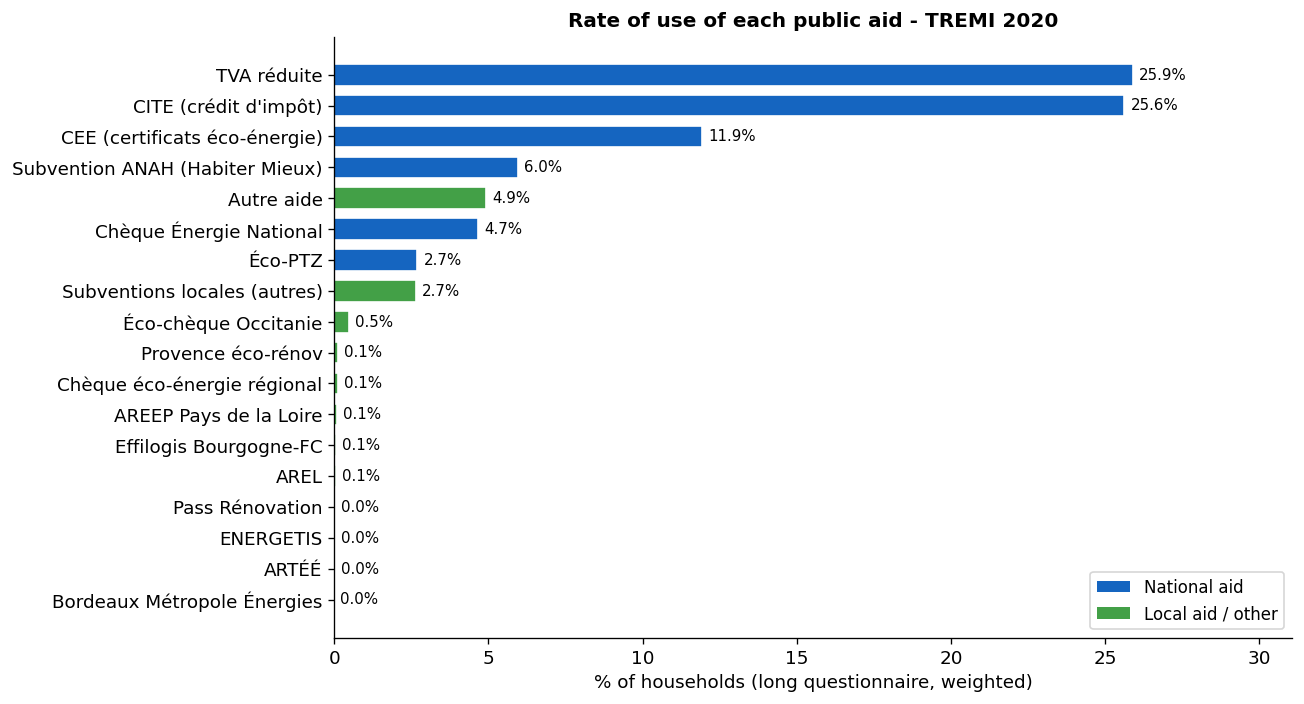

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

nationales = ['CITE (crédit d\'impôt)', 'Éco-PTZ', 'TVA réduite',
              'CEE (certificats éco-énergie)', 'Subvention ANAH (Habiter Mieux)',
              'Chèque Énergie National']
bar_colors = ['#1565C0' if label in nationales else '#43A047' for label in aid_series.index]

bars = ax.barh(aid_series.index, aid_series.values, color=bar_colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, aid_series.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

legend_elements = [
    Patch(facecolor='#1565C0', label='National aid'),
    Patch(facecolor='#43A047', label='Local aid / other'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xlabel("% of households (long questionnaire, weighted)", fontsize=11)
ax.set_title("Rate of use of each public aid - TREMI 2020", fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, aid_series.max() * 1.2)

plt.tight_layout()
plt.savefig('figures/fig2_types_aides.png', bbox_inches='tight')
plt.show()

#### 1.3 Knowledge of the systems vs. actual use

In [11]:
# Q70 : knowledge (1=oui 2=non) - all respondents
# We look only the major national aids
Q70_MAIN = {
    'Q70_01': 'CITE',
    'Q70_02': 'Éco-PTZ',
    'Q70_03': 'TVA réduite',
    'Q70_04': 'CEE',
    'Q70_05': 'ANAH\nHabiter Mieux',
    'Q70_16': 'Chèque\nÉnergie',
}

Q71_MAIN_CODE = {'CITE': 1, 'Éco-PTZ': 2, 'TVA réduite': 3,
                 'CEE': 4, 'ANAH\nHabiter Mieux': 5, 'Chèque\nÉnergie': 16}

know_pct = {}
use_pct  = {}

for col, label in Q70_MAIN.items():
    # Knowledge (all respondents with weights)
    mask_know = df[col] == 1
    know_pct[label] = (mask_know * df['wCal']).sum() / df['wCal'].sum() * 100
    
    # Usage (long questionnaire)
    code = Q71_MAIN_CODE[label]
    mask_use = df_long['aids_set'].apply(lambda s: code in s)
    use_pct[label] = (mask_use * df_long['wCal']).sum() / df_long['wCal'].sum() * 100

compare_df = pd.DataFrame({'Knowledge (%)': know_pct, 'Usage (%)': use_pct})
print(compare_df.round(1))

                     Knowledge (%)  Usage (%)
CITE                          52.5       25.6
Éco-PTZ                       26.9        2.7
TVA réduite                   50.3       25.9
CEE                           29.2       11.9
ANAH\nHabiter Mieux           28.4        6.0
Chèque\nÉnergie               24.3        4.7


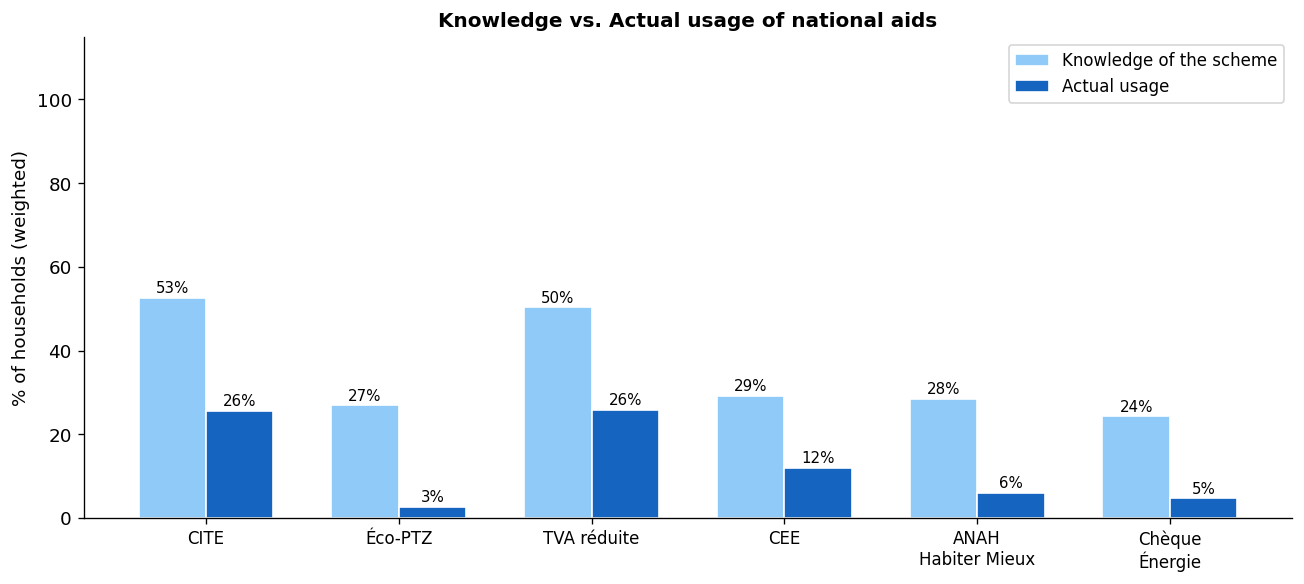

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(compare_df))
w_bar = 0.35
b1 = ax.bar(x - w_bar/2, compare_df['Knowledge (%)'], w_bar,
            label='Knowledge of the scheme', color='#90CAF9', edgecolor='white')
b2 = ax.bar(x + w_bar/2, compare_df['Usage (%)'], w_bar,
            label='Actual usage', color='#1565C0', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, fontsize=10)
ax.set_ylabel('% of households (weighted)', fontsize=11)
ax.set_title('Knowledge vs. Actual usage of national aids', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(compare_df['Knowledge (%)'].max(), 100) * 1.15)

plt.tight_layout()
plt.savefig('figures/fig3_connaissance_utilisation.png', bbox_inches='tight')
plt.show()

#### 1.4 Rate of recourse by type of work

In [13]:
# For each gesture, calculate the rate of recourse to an aid
result_by_work = []
for code, label in WORK_LABELS.items():
    mask_work = df_long[q1_cols].apply(
        lambda row: any(v == code for v in row if pd.notna(v)), axis=1
    )
    sub = df_long[mask_work]
    if len(sub) < 50:
        continue
    n_total = sub['wCal'].sum()
    n_aided = (sub['a_aide'] * sub['wCal']).sum()
    result_by_work.append({
        'geste': label,
        'code': code,
        'pct_aide': n_aided / n_total * 100,
        'n': len(sub),
        'energie': code in ENERGY_GESTES
    })

work_df = pd.DataFrame(result_by_work).sort_values('pct_aide', ascending=False)
print(work_df[['geste', 'pct_aide', 'n', 'energie']].to_string(index=False))

                          geste  pct_aide    n  energie
           Système de chauffage 64.882817 3021     True
     Isolation plancher combles 63.686855 2594     True
       Panneaux photovoltaïques 63.416893  279     True
                  Calorifugeage 59.075835  194     True
    Plancher bas avec isolation 58.882580  749     True
       Fenêtres / baies vitrées 57.568832 3355     True
        Isolation toiture seule 56.902191  655     True
             Portes extérieures 55.467753 1676    False
             Volets / jalousies 55.164642 1442    False
       Murs ext. avec isolation 52.974129  483     True
           Eau chaude sanitaire 52.739534 2014     True
           Régulation chauffage 52.398488  890    False
         Toiture avec isolation 51.298047  855     True
                    Ventilation 48.410702 1222     True
       Murs int. avec isolation 47.755373  992     True
       Murs int. sans isolation 43.276275  814    False
    Plancher bas sans isolation 42.892210  383  

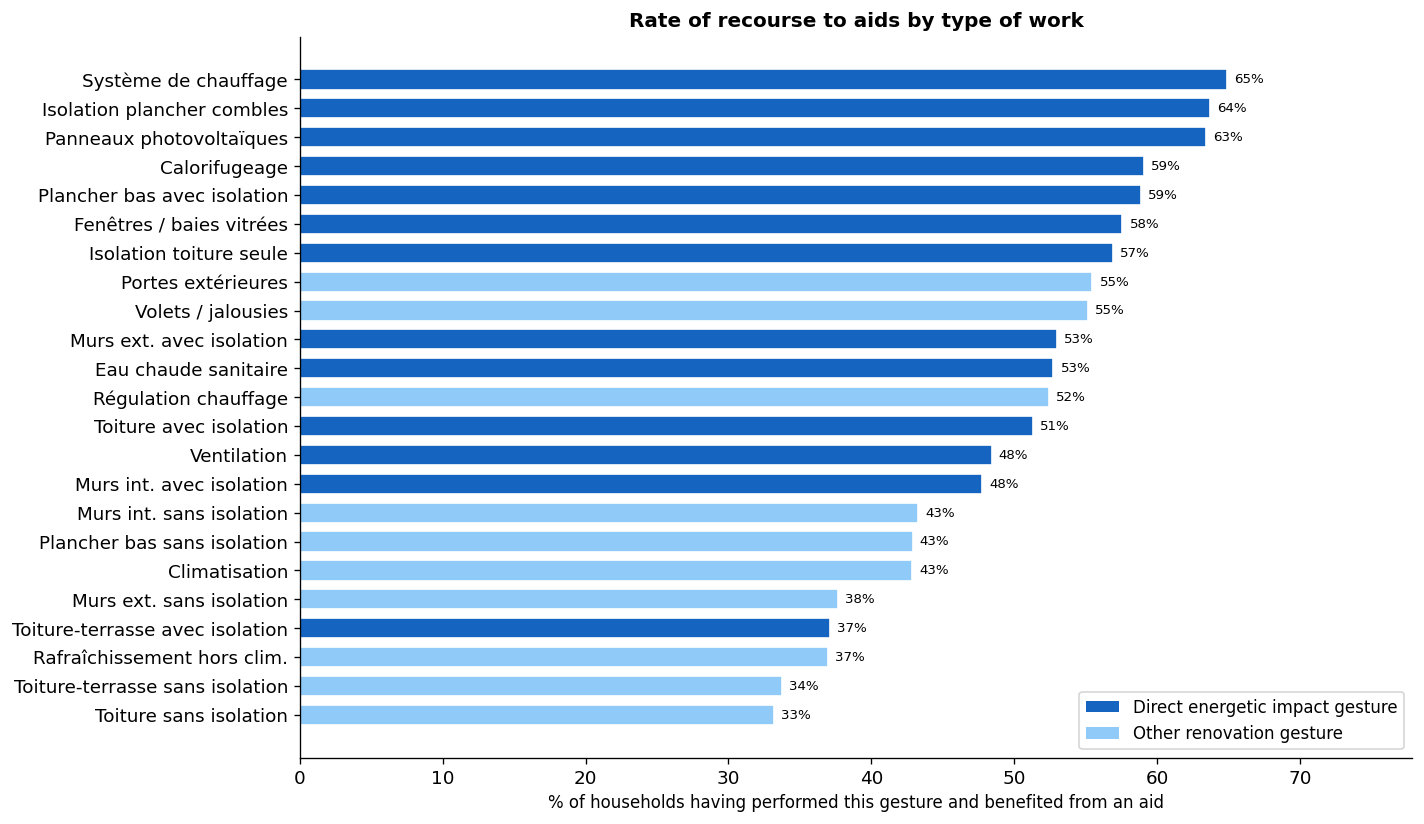

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = ['#1565C0' if e else '#90CAF9' for e in work_df['energie']]
bars = ax.barh(work_df['geste'], work_df['pct_aide'], color=bar_colors,
               edgecolor='white', height=0.7)

for bar, val in zip(bars, work_df['pct_aide']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8)

legend_elements = [
    Patch(facecolor='#1565C0', label='Direct energetic impact gesture'),
    Patch(facecolor='#90CAF9', label='Other renovation gesture'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xlabel('% of households having performed this gesture and benefited from an aid', fontsize=10)
ax.set_title('Rate of recourse to aids by type of work', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, work_df['pct_aide'].max() * 1.2)

plt.tight_layout()
plt.savefig('figures/fig4_aide_par_geste.png', bbox_inches='tight')
plt.show()

#### 1.5 Recourse to aids depending on households characteristics

In [15]:
def pct_aide_by_group(df, group_col, group_labels):
    result = {}
    for code, label in group_labels.items():
        sub = df[df[group_col] == code]
        if sub['wCal'].sum() == 0:
            continue
        result[label] = (sub['a_aide'] * sub['wCal']).sum() / sub['wCal'].sum() * 100
    return pd.Series(result)

INCOME_LABELS  = {1: 'Low (< 18k€)', 2: 'Medium (18–38k€)', 3: 'High (> 38k€)'}
TENURE_LABELS  = {1: 'HLM tenant', 2: 'Tenant (non-HLM)',
                  3: 'Owner (with loan)', 4: 'Owner (without loan)'}
AGE_LABELS     = {1: '18–34 years', 2: '35–49 years', 3: '50 years and above'}
CSP_LABELS     = {1: 'CSP+', 2: 'CSP-', 3: 'Not in the labor force'}

by_income  = pct_aide_by_group(df_long, 'trev',    INCOME_LABELS)
by_tenure  = pct_aide_by_group(df_long, 'Q100',    TENURE_LABELS)
by_age     = pct_aide_by_group(df_long, 'Age_rec', AGE_LABELS)
by_csp     = pct_aide_by_group(df_long, 'CSP',     CSP_LABELS)

print("Rate of recourse to aids by income:\n", by_income.round(1))
print("\nRate of recourse to aids by tenure:\n", by_tenure.round(1))
print("\nRate of recourse by age group:\n", by_age.round(1))
print("\nRate of recourse by CSP:\n", by_csp.round(1))

Rate of recourse to aids by income:
 Low (< 18k€)        49.4
Medium (18–38k€)    49.9
High (> 38k€)       51.2
dtype: float64

Rate of recourse to aids by tenure:
 HLM tenant              17.6
Tenant (non-HLM)        24.3
Owner (with loan)       52.8
Owner (without loan)    54.1
dtype: float64

Rate of recourse by age group:
 18–34 years           47.3
35–49 years           49.3
50 years and above    51.1
dtype: float64

Rate of recourse by CSP:
 CSP+                      53.0
CSP-                      49.1
Not in the labor force    47.3
dtype: float64


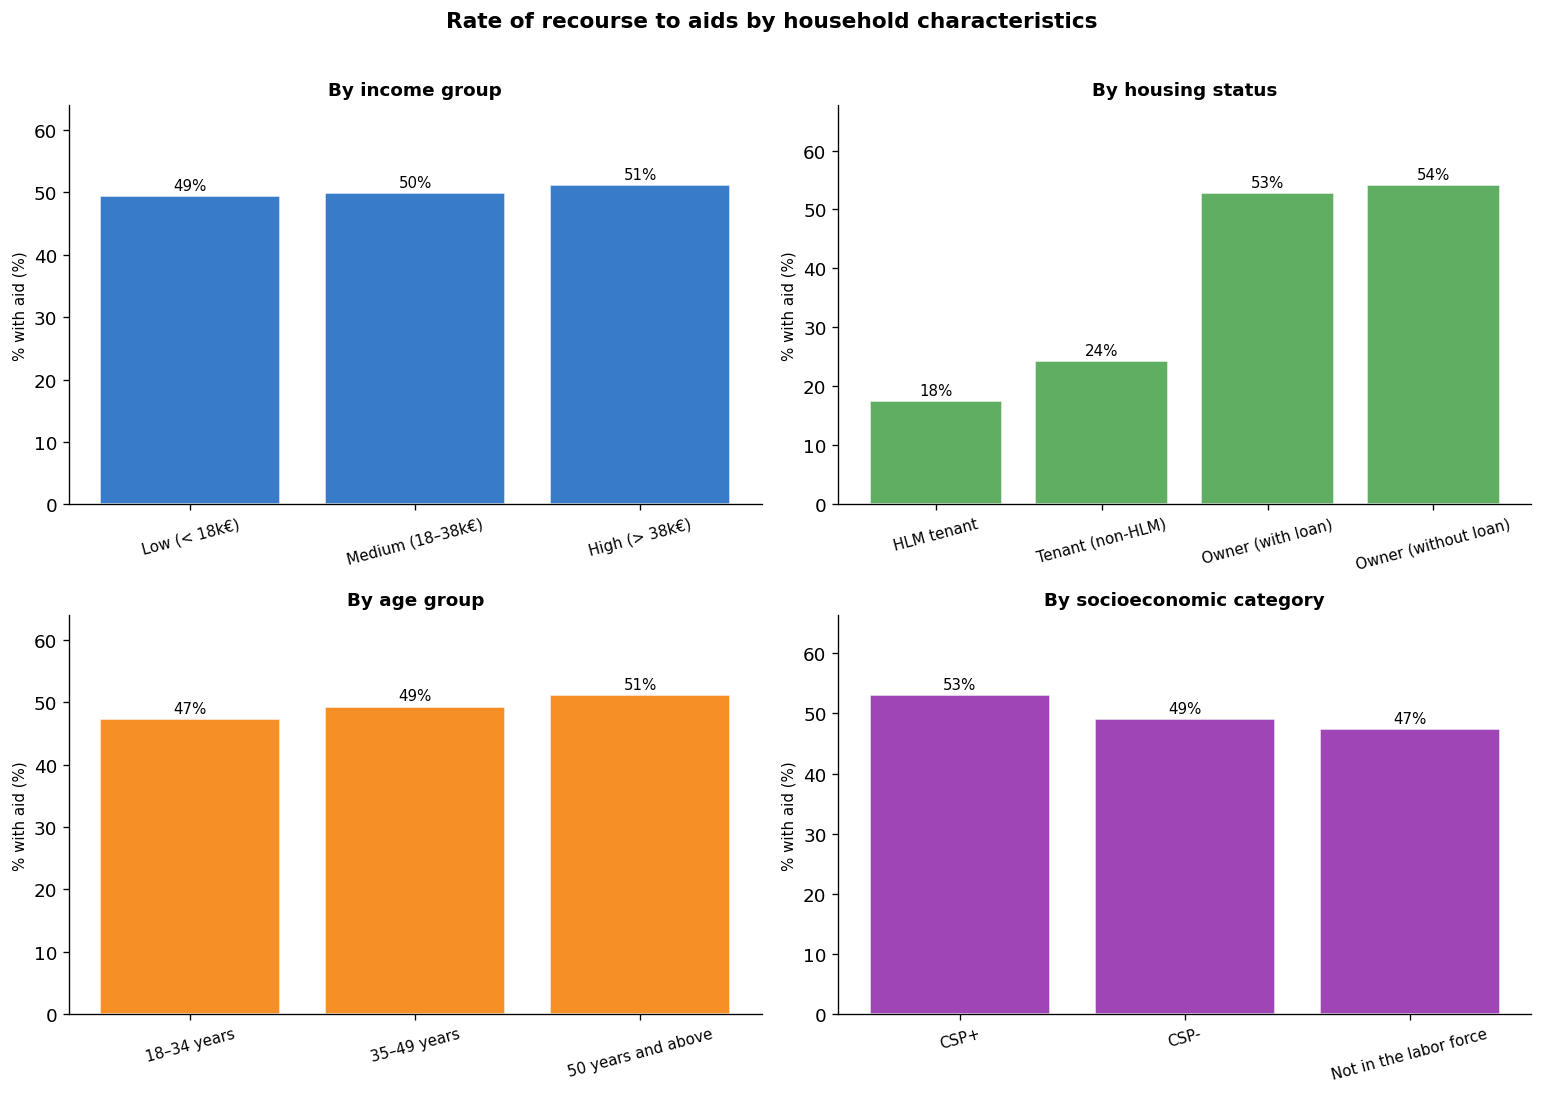

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

datasets = [
    (by_income,'By income group','#1565C0'),
    (by_tenure,'By housing status','#43A047'),
    (by_age,'By age group','#F57C00'),
    (by_csp,'By socioeconomic category','#8E24AA'),
]

for ax, (data, title, color) in zip(axes.flat, datasets):
    bars = ax.bar(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% with aid (%)', fontsize=9)
    ax.set_ylim(0, max(data.values) * 1.25)
    ax.tick_params(axis='x', labelsize=9)
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)

fig.suptitle('Rate of recourse to aids by household characteristics',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig5_aide_par_menage.png', bbox_inches='tight')
plt.show()

### 2. What loan facilities households used most ?

Question Q74 identifies the sources of funding for the work (multiple answers allowed).  
Q75 identifies the amounts by loan type.

#### 2.1 Rate of use of each funding source

In [17]:
# Q74 : funding sources (multi-response)
def get_loans_used(row):
    loans = set()
    for c in q74_cols:
        v = row.get(c)
        if pd.notna(v) and v not in ['_NC_', '_NR_']:
            try:
                loans.add(int(float(v)))
            except:
                pass
    return loans

df_long['loans_set'] = df_long.apply(get_loans_used, axis=1)

# Weighted counting
loan_counts = {}
for code, label in LOAN_LABELS.items():
    mask = df_long['loans_set'].apply(lambda s: code in s)
    loan_counts[label] = (mask * df_long['wCal']).sum() / df_long['wCal'].sum() * 100

loan_series = pd.Series(loan_counts).sort_values(ascending=False)
print("Funding sources (% of households, long questionnaire, weighted) :")
print(loan_series.round(2).to_string())

Funding sources (% of households, long questionnaire, weighted) :
Fonds propres (autofinancement)      61.82
Crédit à la consommation             10.35
Prêt immobilier bancaire              9.55
Autre type de prêt                    4.94
Facilités de paiement fournisseur     4.24
Héritage / donation                   4.04
Éco-PTZ                               3.12
Vente d'une parcelle                  0.36
Surélévation / extension              0.33


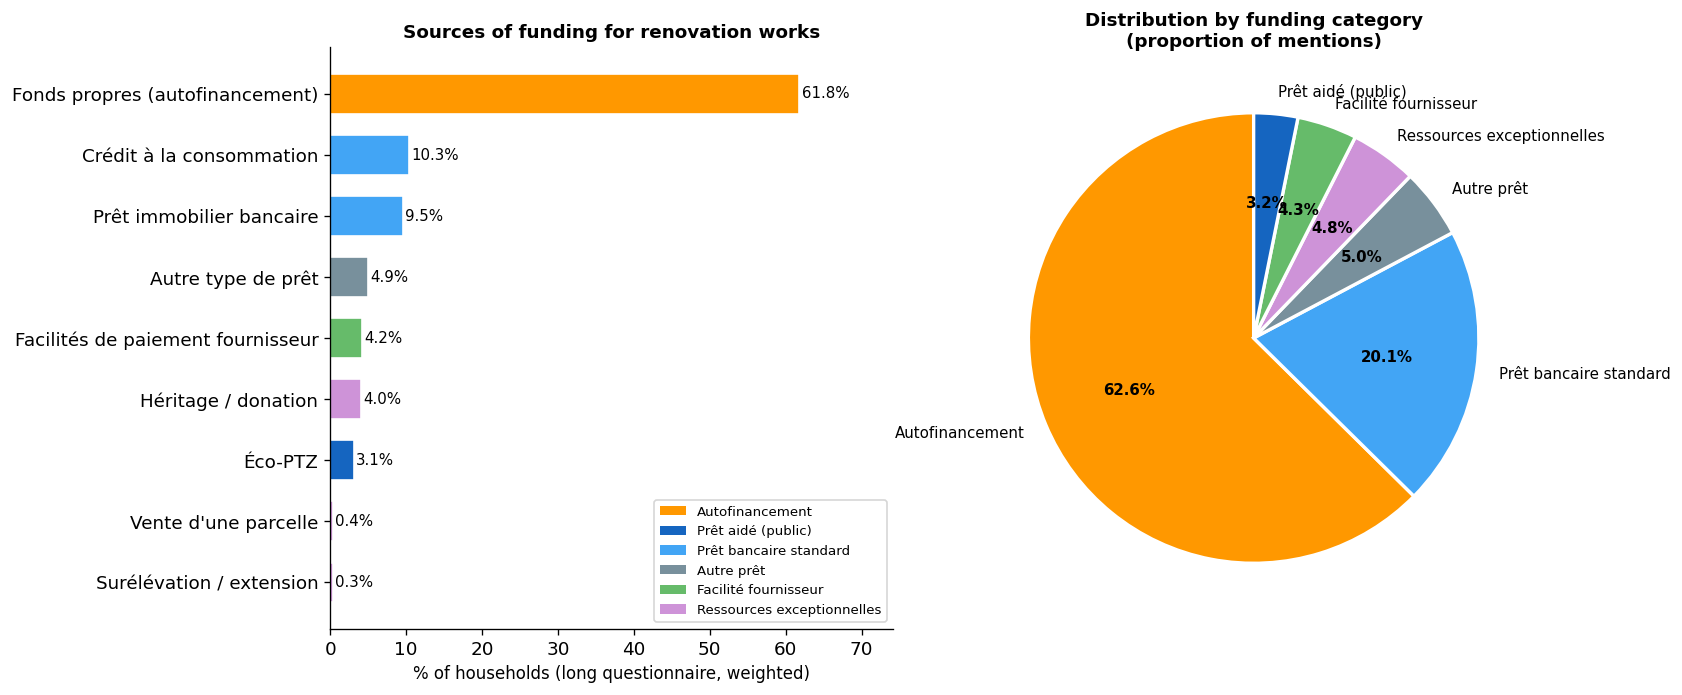

In [18]:
# Catégorisation : prêt aidé / prêt standard / autofinancement / autre
LOAN_CATEGORIES = {
    'Fonds propres (autofinancement)':'Autofinancement',
    'Éco-PTZ':'Prêt aidé (public)',
    'Prêt immobilier bancaire':'Prêt bancaire standard',
    'Crédit à la consommation':'Prêt bancaire standard',
    'Autre type de prêt':'Autre prêt',
    'Facilités de paiement fournisseur':'Facilité fournisseur',
    'Héritage / donation':'Ressources exceptionnelles',
    'Vente d\'une parcelle':'Ressources exceptionnelles',
    'Surélévation / extension':'Ressources exceptionnelles',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
cat_colors = {
    'Autofinancement':         '#FF9800',
    'Prêt aidé (public)':      '#1565C0',
    'Prêt bancaire standard':  '#42A5F5',
    'Autre prêt':              '#78909C',
    'Facilité fournisseur':    '#66BB6A',
    'Ressources exceptionnelles': '#CE93D8',
}
bar_colors_loan = [cat_colors.get(LOAN_CATEGORIES.get(l, 'Autre prêt'), '#78909C')
                   for l in loan_series.index]

bars = ax.barh(loan_series.index, loan_series.values, color=bar_colors_loan,
               edgecolor='white', height=0.65)
for bar, val in zip(bars, loan_series.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of households (long questionnaire, weighted)', fontsize=10)
ax.set_title('Sources of funding for renovation works', fontsize=11, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, loan_series.max() * 1.2)

legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

ax2 = axes[1]
cat_totals = {}
for lbl, val in loan_series.items():
    cat = LOAN_CATEGORIES.get(lbl, 'Autre prêt')
    cat_totals[cat] = cat_totals.get(cat, 0) + val

# Normalization (one household can use multiple sources)
total_mentions = sum(cat_totals.values())
cat_pct = {k: v / total_mentions * 100 for k, v in cat_totals.items()}
cat_s = pd.Series(cat_pct).sort_values(ascending=False)

wedges, texts, autotexts = ax2.pie(
    cat_s.values,
    labels=cat_s.index,
    colors=[cat_colors[k] for k in cat_s.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Distribution by funding category\n(proportion of mentions)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig6_sources_financement.png', bbox_inches='tight')
plt.show()

#### 2.2 Loan amounts (Q75)

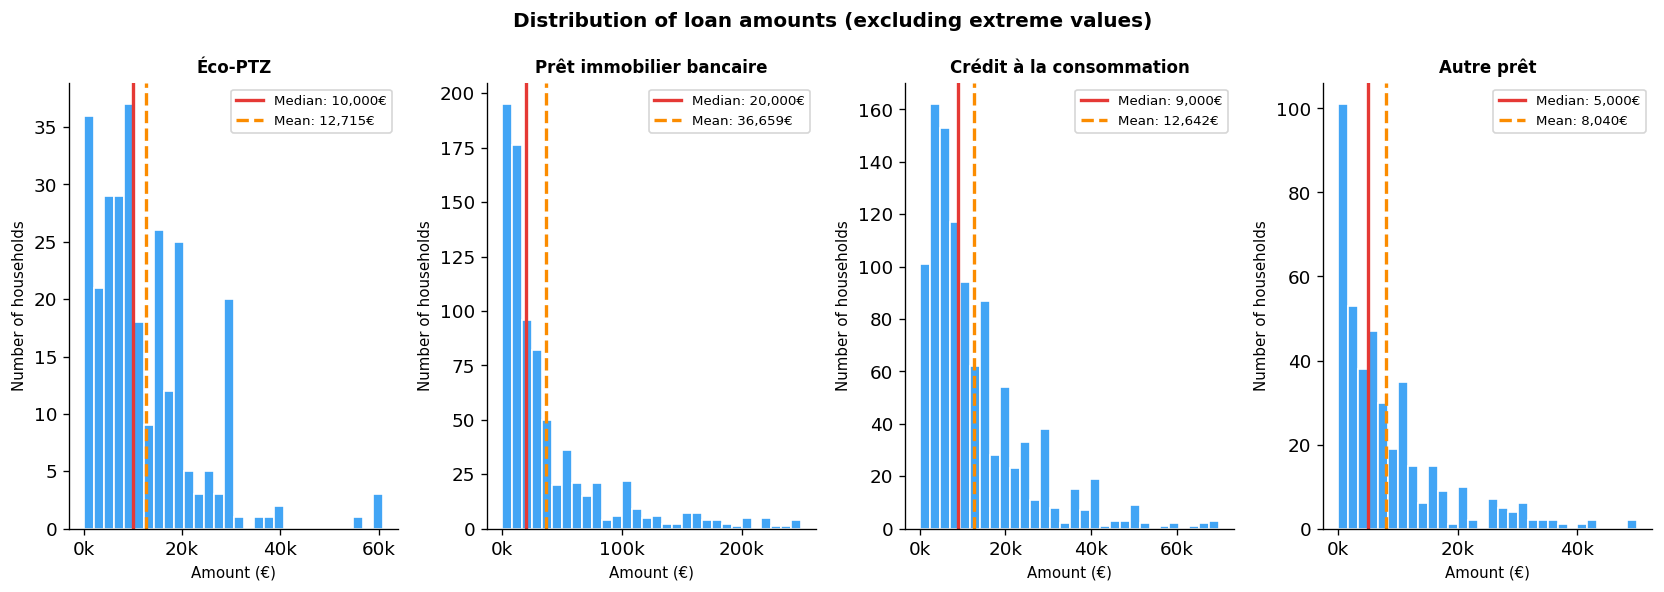

In [19]:
Q75_LABELS = {
    'Q75_01': 'Éco-PTZ',
    'Q75_02': 'Prêt immobilier bancaire',
    'Q75_03': 'Crédit à la consommation',
    'Q75_04': 'Autre prêt',
}

fig, axes = plt.subplots(1, len(Q75_LABELS), figsize=(14, 5), sharey=False)

for ax, (col, label) in zip(axes, Q75_LABELS.items()):
    amounts = pd.to_numeric(df_long[col], errors='coerce').dropna()
    # filter outliers > 99e percentile
    p99 = amounts.quantile(0.99)
    amounts_clean = amounts[amounts <= p99]
    if len(amounts_clean) < 20:
        ax.set_visible(False)
        continue
    ax.hist(amounts_clean, bins=30, color='#42A5F5', edgecolor='white')
    ax.axvline(amounts_clean.median(), color='#E53935', linewidth=2,
               label=f'Median: {amounts_clean.median():,.0f}€')
    ax.axvline(amounts_clean.mean(), color='#FB8C00', linewidth=2, linestyle='--',
               label=f'Mean: {amounts_clean.mean():,.0f}€')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Amount (€)', fontsize=9)
    ax.set_ylabel('Number of households', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

fig.suptitle('Distribution of loan amounts (excluding extreme values)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig7_montants_prets.png', bbox_inches='tight')
plt.show()

#### 2.3 Use of the Eco-PTZ by income and housing status

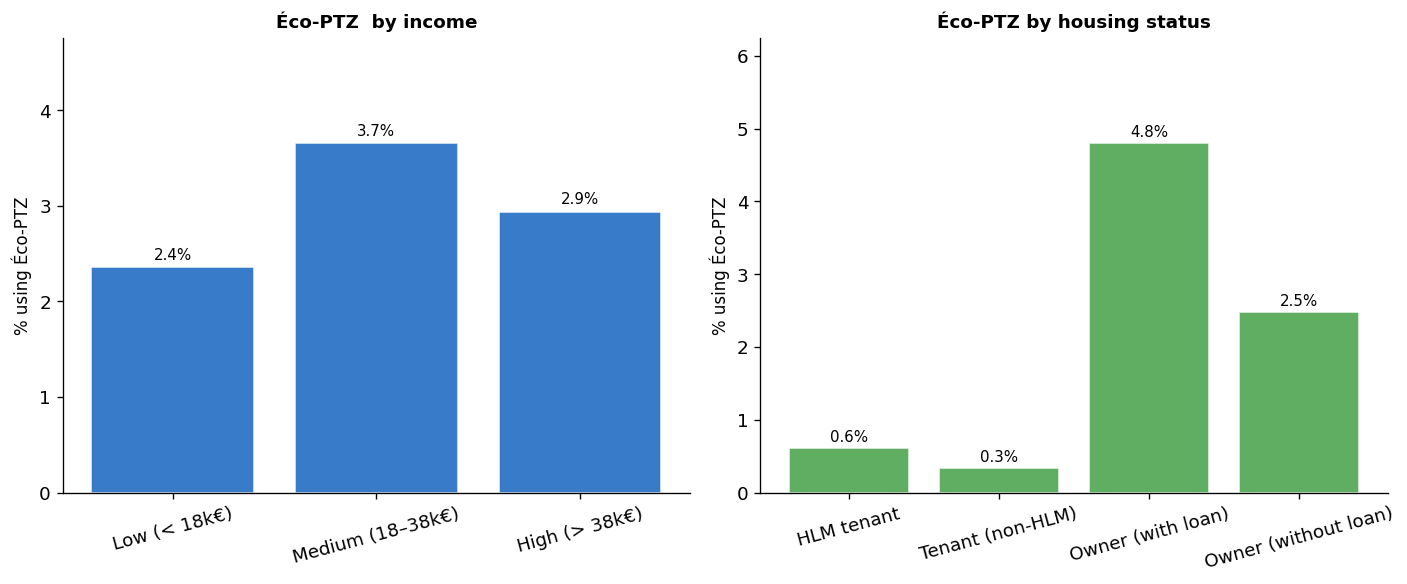

In [20]:
# Code 1 = Éco-PTZ in Q74
df_long['uses_ecoptz'] = df_long['loans_set'].apply(lambda s: 1 in s)

ecoptz_income = {}
for code, label in INCOME_LABELS.items():
    sub = df_long[df_long['trev'] == code]
    if sub['wCal'].sum() == 0: continue
    ecoptz_income[label] = (sub['uses_ecoptz'] * sub['wCal']).sum() / sub['wCal'].sum() * 100

ecoptz_tenure = {}
for code, label in TENURE_LABELS.items():
    sub = df_long[df_long['Q100'] == code]
    if sub['wCal'].sum() == 0: continue
    ecoptz_tenure[label] = (sub['uses_ecoptz'] * sub['wCal']).sum() / sub['wCal'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, color in [
    (axes[0], ecoptz_income, 'Éco-PTZ  by income', '#1565C0'),
    (axes[1], ecoptz_tenure, "Éco-PTZ by housing status", '#43A047'),
]:
    bars = ax.bar(list(data.keys()), list(data.values()), color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, data.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('% using Éco-PTZ', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(data.values()) * 1.3 if data else 10)
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.savefig('figures/fig8_ecoptz_profils.png', bbox_inches='tight')
plt.show()

### 3. How prevalent policy interactions were ?

Here we analyze:
- How many types of aids households receive
- Which combinations are most common
- The stated role of the assistance in the decision to undertake renovations (Q72)

#### 3.1 Distribution du nombre d'aides cumulées

In [21]:
# Among the households having at least one aid
df_aided = df_long[df_long['a_aide']].copy()

n_aid_dist_aided = df_aided.groupby('n_aides').apply(lambda g: g['wCal'].sum())
n_aid_pct_aided = n_aid_dist_aided / n_aid_dist_aided.sum() * 100

# For all households (including those without aid)
n_all = df_long.groupby('n_aides').apply(lambda g: g['wCal'].sum())
n_all_pct = n_all / n_all.sum() * 100

print("Distribution of the number of aids (households with at least one aid):")
print(n_aid_pct_aided.round(1))

pct_2plus = n_aid_pct_aided[n_aid_pct_aided.index >= 2].sum()
print(f"\n➡ {pct_2plus:.1f}% of aided households have 2 aids or more")

Distribution of the number of aids (households with at least one aid):
n_aides
1    53.7
2    29.0
3    12.7
4     3.4
5     1.0
6     0.2
7     0.0
dtype: float64

➡ 46.3% of aided households have 2 aids or more


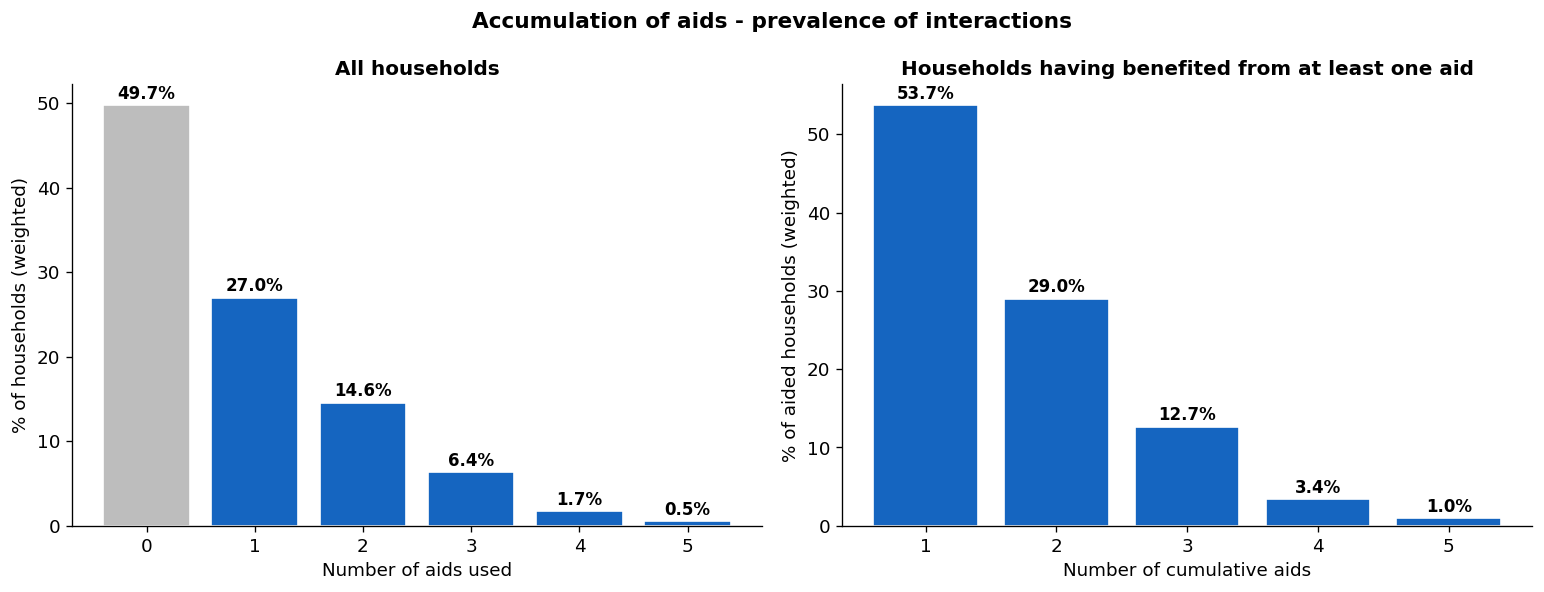

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
n_plot = n_all_pct[n_all_pct.index <= 5]
bar_colors_n = ['#BDBDBD' if i == 0 else '#1565C0' for i in n_plot.index]
bars = ax.bar(n_plot.index.astype(str), n_plot.values, color=bar_colors_n, edgecolor='white')
for bar, val in zip(bars, n_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel("Number of aids used", fontsize=11)
ax.set_ylabel('% of households (weighted)', fontsize=11)
ax.set_title('All households', fontsize=12, fontweight='bold')

ax2 = axes[1]
n_plot2 = n_aid_pct_aided[n_aid_pct_aided.index <= 5]
bars2 = ax2.bar(n_plot2.index.astype(str), n_plot2.values,
                color='#1565C0', edgecolor='white')
for bar, val in zip(bars2, n_plot2.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xlabel("Number of cumulative aids", fontsize=11)
ax2.set_ylabel('% of aided households (weighted)', fontsize=11)
ax2.set_title('Households having benefited from at least one aid', fontsize=12, fontweight='bold')

fig.suptitle('Accumulation of aids - prevalence of interactions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig9_cumul_aides.png', bbox_inches='tight')
plt.show()

#### 3.2 Most common combinations of aids

In [23]:
# Main aids for readibility
MAIN_AIDS = {1: 'CITE', 2: 'Éco-PTZ', 3: 'TVA', 4: 'CEE', 5: 'ANAH'}

def simplify_aids(aids_set):
    main = frozenset(MAIN_AIDS[a] for a in aids_set if a in MAIN_AIDS)
    has_local = any(a in [6,7,8,9,10,11,12,13,14,15,16,17,22] for a in aids_set)
    if has_local:
        main = main | frozenset(['Locale'])
    return main

df_aided['aids_simplified'] = df_aided['aids_set'].apply(simplify_aids)
df_aided['aids_str'] = df_aided['aids_simplified'].apply(
    lambda s: ' + '.join(sorted(s)) if s else 'Autre'
)

combo_counts = df_aided.groupby('aids_str').apply(lambda g: g['wCal'].sum())
combo_pct = combo_counts / df_aided['wCal'].sum() * 100
combo_pct = combo_pct.sort_values(ascending=False).head(15)

print("Top 15 combinations of aids (% of aided households) :")
print(combo_pct.round(2).to_string())

Top 15 combinations of aids (% of aided households) :
aids_str
CITE                   16.40
CITE + TVA             15.61
TVA                    14.77
Locale                 12.26
CEE                     6.37
CEE + CITE + TVA        6.16
ANAH                    3.10
CEE + TVA               2.66
CEE + CITE              2.62
Locale + TVA            1.86
CITE + Locale + TVA     1.77
CITE + Locale           1.55
ANAH + Locale           1.37
Éco-PTZ                 1.16
ANAH + TVA              0.78


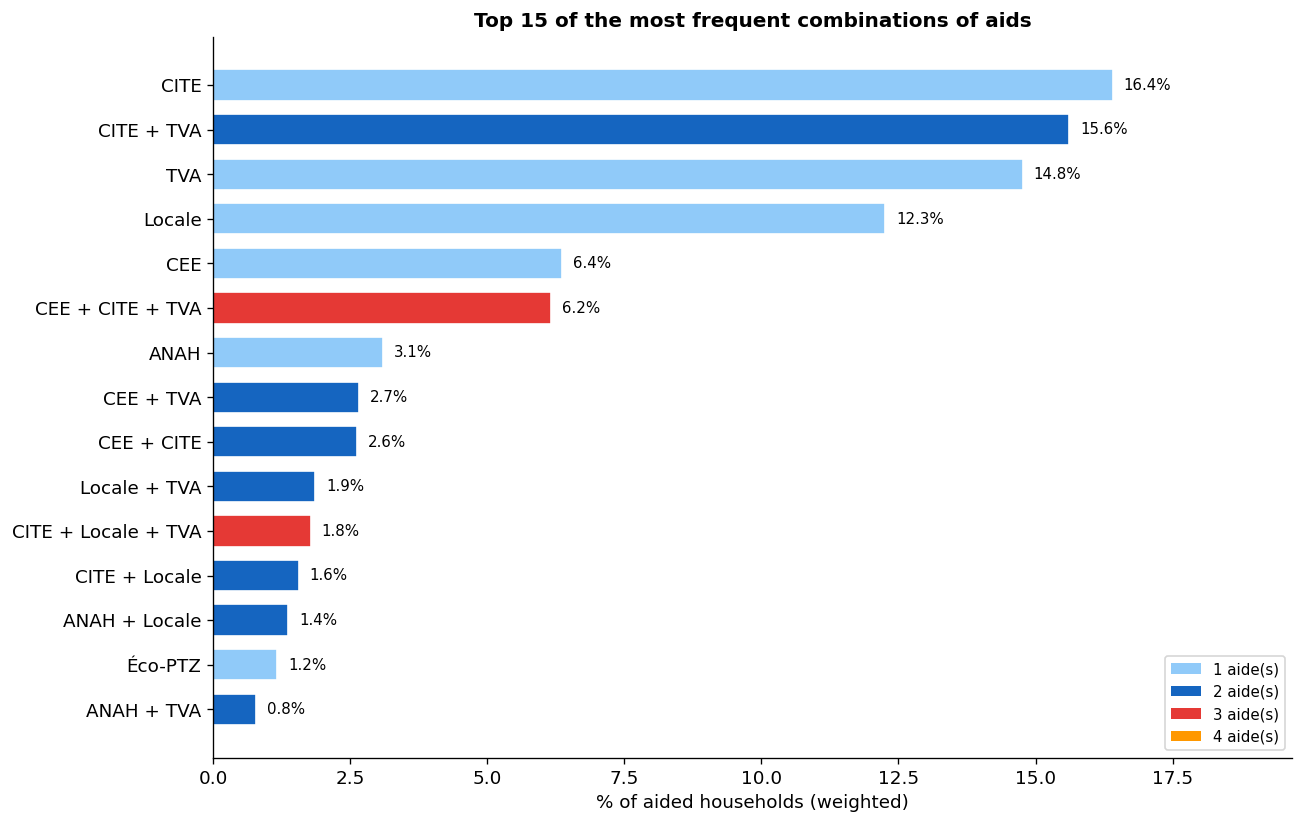

In [24]:
fig, ax = plt.subplots(figsize=(11, 7))

n_aids_per_combo = combo_pct.index.map(lambda s: len(s.split(' + ')))
palette = {1: '#90CAF9', 2: '#1565C0', 3: '#E53935', 4: '#FF9800', 5: '#7B1FA2'}
bar_colors_c = [palette.get(n, '#78909C') for n in n_aids_per_combo]

bars = ax.barh(combo_pct.index, combo_pct.values, color=bar_colors_c, edgecolor='white', height=0.7)
for bar, val in zip(bars, combo_pct.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

legend_elements = [Patch(facecolor=v, label=f'{k} aide(s)') for k, v in palette.items() if k <= 4]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.set_xlabel('% of aided households (weighted)', fontsize=11)
ax.set_title('Top 15 of the most frequent combinations of aids', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, combo_pct.max() * 1.2)

plt.tight_layout()
plt.savefig('figures/fig10_combinaisons_aides.png', bbox_inches='tight')
plt.show()

#### 3.3 Co-occurrence matrix of aid (correlations)

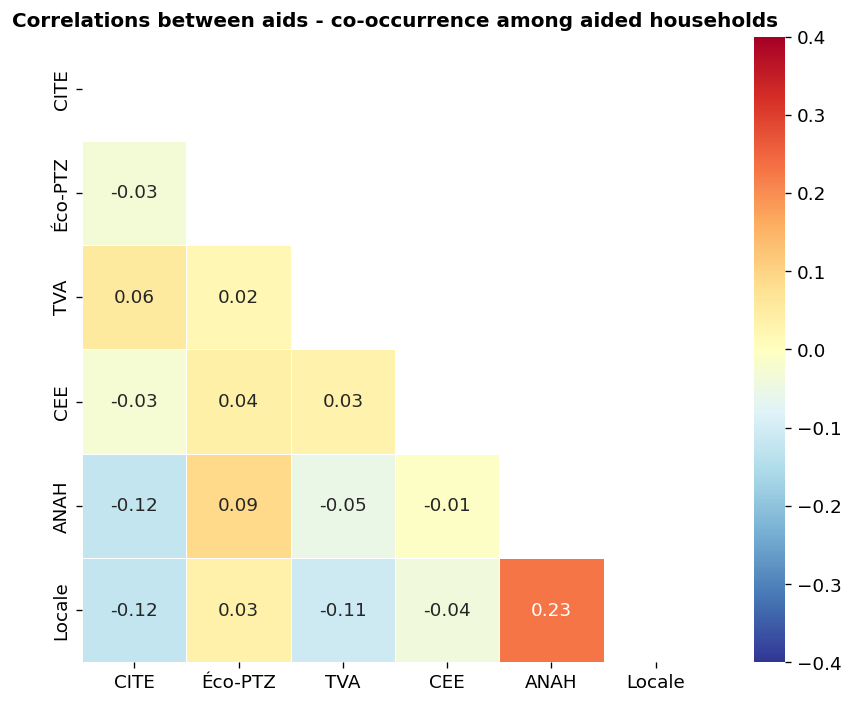

In [25]:
for code, label in MAIN_AIDS.items():
    df_aided[f'aid_{label}'] = df_aided['aids_set'].apply(lambda s: 1 if code in s else 0)
df_aided['aid_Locale'] = df_aided['aids_set'].apply(
    lambda s: 1 if any(a in [6,7,8,9,10,11,12,13,14,15,16,17] for a in s) else 0
)

aid_bin_cols = ['aid_CITE', 'aid_Éco-PTZ', 'aid_TVA', 'aid_CEE', 'aid_ANAH', 'aid_Locale']
corr_matrix = df_aided[aid_bin_cols].rename(
    columns={c: c.replace('aid_', '') for c in aid_bin_cols}
).corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-0.4, vmax=0.4,
    ax=ax, square=True, linewidths=0.5,
    annot_kws={'size': 11}
)
ax.set_title('Correlations between aids - co-occurrence among aided households',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig11_cooccurrence_aides.png', bbox_inches='tight')
plt.show()

#### 3.4 Role of financial aid in the decision to undertake construction work (Q72)

In [26]:
Q72_LABELS = {
    'Q72_1': 'Allowed to launch the project',
    'Q72_2': 'Allowed to deal with a breakdown',
    'Q72_3': 'Allowed to do more work',
    'Q72_4': 'Allowed to improve quality',
    'Q72_5': 'Allowed to reduce costs',
    'Q72_6': 'Allowed to consult an expert',
}

q72_df = df_aided.dropna(subset=q72_cols, how='all')

q72_pct_yes = {}
for col, label in Q72_LABELS.items():
    mask = q72_df[col] == 1  # 1 = oui
    q72_pct_yes[label] = (mask * q72_df['wCal']).sum() / q72_df['wCal'].sum() * 100

q72_series = pd.Series(q72_pct_yes).sort_values(ascending=False)
print("Role of the aid according to households (Q72, % yes, weighted) :")
print(q72_series.round(2).to_string())

Role of the aid according to households (Q72, % yes, weighted) :
Allowed to reduce costs             79.73
Allowed to consult an expert        73.92
Allowed to launch the project       54.26
Allowed to improve quality          48.67
Allowed to do more work             23.87
Allowed to deal with a breakdown    11.70


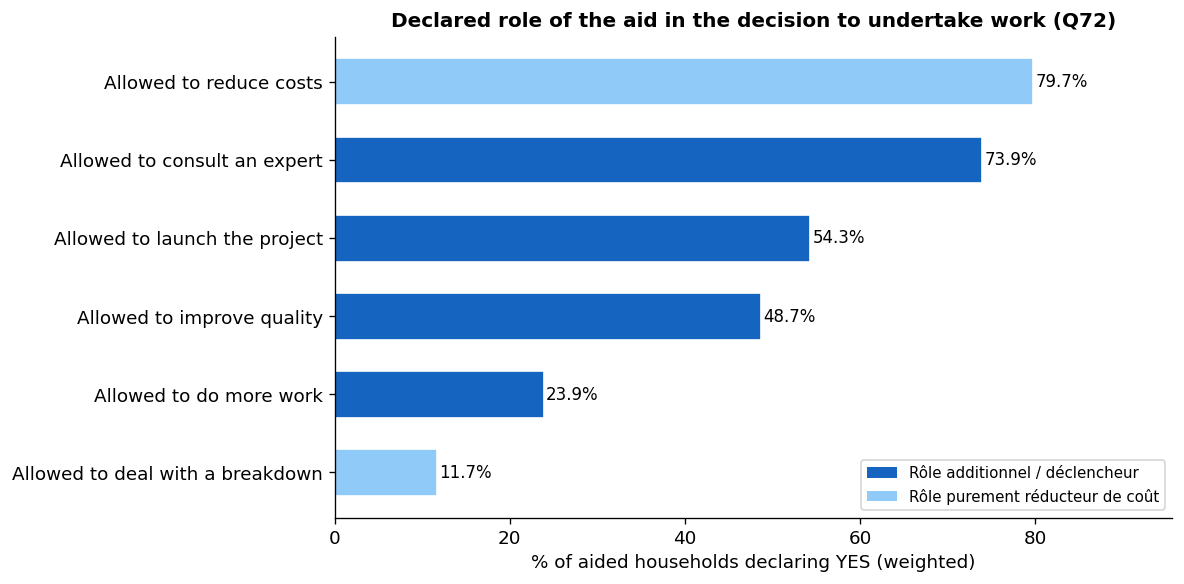

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

additionnel = ['Allowed to launch the project', 'Allowed to do more work',
               'Allowed to improve quality', 'Allowed to consult an expert']
bar_colors_q72 = ['#1565C0' if l in additionnel else '#90CAF9' for l in q72_series.index]

bars = ax.barh(q72_series.index, q72_series.values, color=bar_colors_q72, edgecolor='white', height=0.6)
for bar, val in zip(bars, q72_series.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

legend_elements = [
    Patch(facecolor='#1565C0', label='Rôle additionnel / déclencheur'),
    Patch(facecolor='#90CAF9', label='Rôle purement réducteur de coût'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.set_xlabel('% of aided households declaring YES (weighted)', fontsize=11)
ax.set_title("Declared role of the aid in the decision to undertake work (Q72)", fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, q72_series.max() * 1.2)

plt.tight_layout()
plt.savefig('figures/fig12_role_aide.png', bbox_inches='tight')
plt.show()

#### 3.5 Total amount of aid received (Q73)

In [28]:
df_long['montant_aide'] = pd.to_numeric(df_long['Q73'], errors='coerce')

montants = df_long['montant_aide'].dropna()
montants = montants[montants > 0]
p99 = montants.quantile(0.99)
montants_clean = montants[montants <= p99]

print(f"N households with aid amount reported : {len(montants):,}")
print(f"Median aid amount received : {montants_clean.median():,.0f} €")
print(f"Mean aid amount received : {montants_clean.mean():,.0f} €")
print(f"Percentile 75 : {montants_clean.quantile(0.75):,.0f} €")
print(f"Percentile 90 : {montants_clean.quantile(0.90):,.0f} €")

N households with aid amount reported : 3,427
Median aid amount received : 1,700 €
Mean aid amount received : 2,800 €
Percentile 75 : 3,500 €
Percentile 90 : 7,000 €


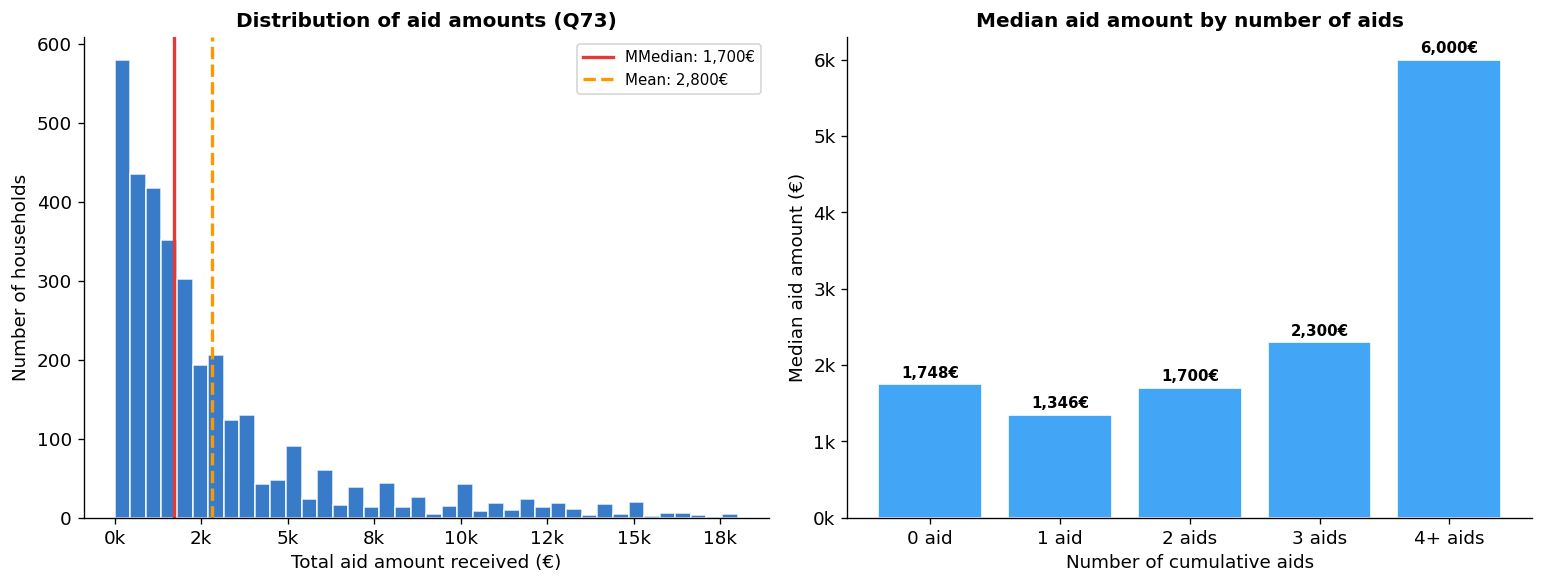

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(montants_clean, bins=40, color='#1565C0', edgecolor='white', alpha=0.85)
ax.axvline(montants_clean.median(), color='#E53935', lw=2, label=f'MMedian: {montants_clean.median():,.0f}€')
ax.axvline(montants_clean.mean(),   color='#FF9800', lw=2, ls='--', label=f'Mean: {montants_clean.mean():,.0f}€')
ax.set_xlabel('Total aid amount received (€)', fontsize=11)
ax.set_ylabel('Number of households', fontsize=11)
ax.set_title('Distribution of aid amounts (Q73)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Montant selon nombre d'aides
ax2 = axes[1]
df_montant = df_long[df_long['montant_aide'] > 0].copy()
df_montant['n_aides_cat'] = df_montant['n_aides'].clip(0, 4).map(
    {0: '0 aid', 1: '1 aid', 2: '2 aids', 3: '3 aids', 4: '4+ aids'}
)
medians = df_montant.groupby('n_aides_cat')['montant_aide'].median()
bars = ax2.bar(medians.index, medians.values, color='#42A5F5', edgecolor='white')
for bar, val in zip(bars, medians.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}€', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel("Number of cumulative aids", fontsize=11)
ax2.set_ylabel('Median aid amount (€)', fontsize=11)
ax2.set_title('Median aid amount by number of aids', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('figures/fig13_montant_aides.png', bbox_inches='tight')
plt.show()

#### 3.6 Interactions: aid based on the number of energy-related actions

In [30]:
def count_energy_gestes(row):
    gestes = set()
    for c in q1_cols:
        v = row.get(c)
        if pd.notna(v) and int(v) in ENERGY_GESTES:
            gestes.add(int(v))
    return len(gestes)

df_long['n_energy_gestes'] = df_long.apply(count_energy_gestes, axis=1)

geste_aid = df_long.groupby('n_energy_gestes').apply(
    lambda g: pd.Series({
        'pct_aide': (g['a_aide'] * g['wCal']).sum() / g['wCal'].sum() * 100,
        'n_aides_moy': (g['n_aides'] * g['wCal']).sum() / g['wCal'].sum(),
        'n': len(g)
    })
)
geste_aid = geste_aid[geste_aid['n'] >= 30]
print(geste_aid.round(2))

                 pct_aide  n_aides_moy       n
n_energy_gestes                               
0                   22.00         0.30  1455.0
1                   49.40         0.76  4688.0
2                   60.70         1.10  2290.0
3                   64.64         1.22   992.0
4                   59.24         1.24   465.0
5                   57.53         1.10   216.0
6                   56.16         1.39   111.0
7                   56.63         1.25    46.0


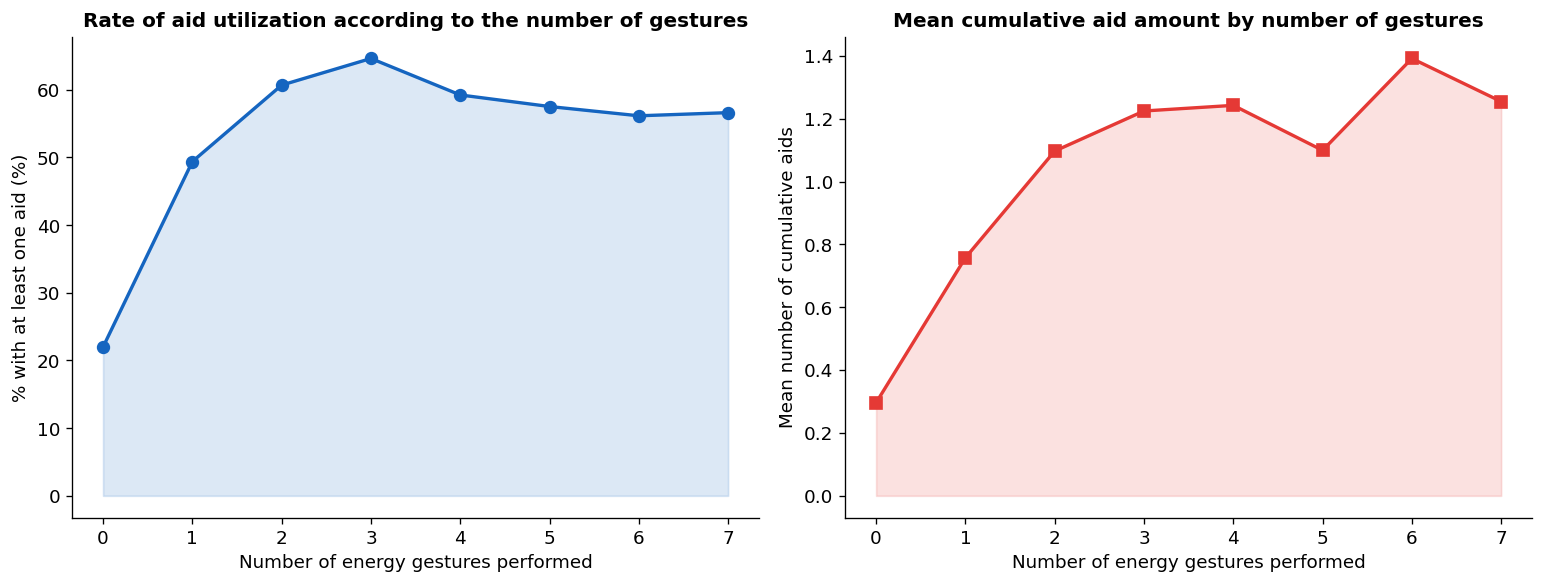

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(geste_aid.index, geste_aid['pct_aide'], 'o-', color='#1565C0', lw=2, ms=7)
ax.fill_between(geste_aid.index, geste_aid['pct_aide'], alpha=0.15, color='#1565C0')
ax.set_xlabel('Number of energy gestures performed', fontsize=11)
ax.set_ylabel('% with at least one aid (%)', fontsize=11)
ax.set_title('Rate of aid utilization according to the number of gestures', fontsize=12, fontweight='bold')
ax.set_xticks(geste_aid.index)

ax2 = axes[1]
ax2.plot(geste_aid.index, geste_aid['n_aides_moy'], 's-', color='#E53935', lw=2, ms=7)
ax2.fill_between(geste_aid.index, geste_aid['n_aides_moy'], alpha=0.15, color='#E53935')
ax2.set_xlabel('Number of energy gestures performed', fontsize=11)
ax2.set_ylabel('Mean number of cumulative aids', fontsize=11)
ax2.set_title('Mean cumulative aid amount by number of gestures', fontsize=12, fontweight='bold')
ax2.set_xticks(geste_aid.index)

plt.tight_layout()
plt.savefig('figures/fig14_gestes_aides.png', bbox_inches='tight')
plt.show()

# 4. Aid additionality in energy renovation - instrumental variable approach  

## 4.1. The core identification problem  
We want to estimate the **counterfactual**: *would household i have renovated (or renovated as deeply) without the aid?*  

The fundamental challenge is that aid recipients are not randomly assigned. Households who apply for aids are systematically different from those who do not — they may be more motivated, better informed, or wealthier. A naive OLS comparison of aided vs. non-aided households yields a biased estimate of the true additionality effect. The Instrumental Variable (IV) strategy resolves this by finding an external source of variation in aid uptake that is unrelated to unobserved motivation.  

### The IV assumption  

A valid instrument $Z_i$ must satisfy three conditions:

| Condition | Formal Statement | Interpretation in our context |
|---|---|---|
| **Relevance** | $\text{Cov}(Z_i, D_i) \neq 0$ | Awareness (Q70) predicts aid uptake (Q71) |
| **Exclusion** | $\text{Cov}(Z_i, \varepsilon_i) = 0$ | Awareness affects renovation *only* through aid uptake |
| **Independence** | $Z_i \perp (Y_{0i}, Y_{1i})$ | Awareness is uncorrelated with unobserved renovation motivation |

**Critical caveat on the exclusion restriction:** If households who are *more motivated* to renovate also *actively seek out* information about aids, then $Z_i$ (awareness) would be endogenous. The instrument is most credible when awareness is driven by **passive exposure** (media campaigns, neighbours, local outreach) rather than active search behaviour.

---

## 4.2. The Formal 2SLS Model

We use **Two-Stage Least Squares (2SLS)** with the following variables:

| Symbol | Variable | Source |
|---|---|---|
| $Z_i$ | Awareness of at least one national aid (binary) | Q70 |
| $D_i$ | Receipt of at least one aid (binary, **endogenous**) | Q71 |
| $Y_i$ | Renovation depth: number of energy gestures $n\_energy\_gestes$ | Q1 |
| $X_i$ | Controls: income (`trev`), age (`Age_rec`), CSP, tenure (`Q100`) | — |
| $w_i$ | Survey sampling weight | `wCal` |

### Stage 1 — First stage (predict aid uptake)

$$
\hat{D}_i = \hat{\alpha}_0 + \hat{\alpha}_1 Z_i + \hat{\alpha}_2 X_i + \hat{\varepsilon}_i
$$

This stage checks **instrument relevance**: we need $\hat{\alpha}_1$ to be large and statistically significant (first-stage $F$-statistic $> 10$).

### Stage 2 — Second stage (causal effect on renovation depth)

$$
Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2 X_i + \eta_i
$$

The coefficient $\beta_1$ is the **Local Average Treatment Effect (LATE)**:

$$
\text{LATE} = \frac{\text{Cov}(Y_i, Z_i)}{\text{Cov}(D_i, Z_i)} = \mathbb{E}[Y_{1i} - Y_{0i} \mid \text{Compliers}]
$$

It captures the additionality effect **for compliers** — households whose aid uptake was *caused* by their awareness of the scheme.

---

### Key Diagnostics

| Test | Purpose | Threshold |
|---|---|---|
| **First-stage $F$-statistic** | Instrument strength | $F > 10$ (Staiger & Stock, 1997) |
| **Wu-Hausman test** | Is OLS bias significant? | $p < 0.05$ → endogeneity confirmed, IV preferred |
| **Sargan–Hansen $J$-test** | Over-identification (only with $\geq 2$ instruments) | $p > 0.05$ → instruments valid |

---


### Interpretation

The 2SLS estimate of $\beta_1$ answers:

> *Among households who used an aid **because** they were aware of it, how many additional energy gestures did the aid cause them to undertake?*

A positive and significant $\beta_1$ is evidence of **genuine additionality** — the policy triggered deeper renovations that would not have occurred otherwise.

This can be further validated against the self-reported additionality question **Q72** ("the aid allowed me to launch the project"), which serves as a qualitative robustness check on the IV estimate.


## 4.3 Data Preparation

In [35]:
# ── Column groups ───────────────────────────────────────
q1_cols  = [f'Q1_{i}' for i in range(1, 24)]
q70_cols = [c for c in df.columns if c.startswith('Q70_')]
q71_cols = [f'Q71_{i}' for i in range(1, 9)]

ENERGY_GESTES = [11, 13, 14, 15, 21, 23, 31, 41, 51, 53, 54, 55, 58]

# ── Sub-sample : long questionnaire ────────────────────────────────────────
df_long = df[df['Recode_Court_Long'] == 1].copy()

# ── Outcome : number of energy gestures ────────────────────────────────────
def count_energy_gestes(row):
    gestes = set()
    for c in q1_cols:
        v = row.get(c)
        if pd.notna(v):
            try:
                if int(v) in ENERGY_GESTES:
                    gestes.add(int(v))
            except:
                pass
    return len(gestes)

df_long['n_energy_gestes'] = df_long.apply(count_energy_gestes, axis=1)

# ── Treatment : received at least one aid ──────────────────────────────────
def get_aids_used(row):
    aids = set()
    for c in q71_cols:
        v = row.get(c)
        if pd.notna(v):
            try:
                aids.add(int(v))
            except:
                pass
    return aids

df_long['aids_set'] = df_long.apply(get_aids_used, axis=1)
df_long['a_aide'] = df_long['aids_set'].apply(
    lambda s: int(len(s) > 0 and s != {23})
)

# ── Instrument : aware of at least one major national aid (Q70) ────────────
# Q70_01=CITE, Q70_02=Eco-PTZ, Q70_03=TVA, Q70_04=CEE, Q70_05=ANAH
Q70_MAIN = ['Q70_01', 'Q70_02', 'Q70_03', 'Q70_04', 'Q70_05']
df_long['aware_any'] = df_long[Q70_MAIN].apply(
    lambda row: int(any(row == 1)), axis=1
)
# Richer instrument : number of aids the household is aware of
df_long['aware_score'] = df_long[Q70_MAIN].apply(
    lambda row: (row == 1).sum(), axis=1
)

# ── Controls ────────────────────────────────────────────────────────────────
# Dummies for income, tenure, age, CSP
df_long['income_med']  = (df_long['trev'] == 2).astype(int)
df_long['income_high'] = (df_long['trev'] == 3).astype(int)
df_long['owner_loan']  = (df_long['Q100'] == 3).astype(int)
df_long['owner_free']  = (df_long['Q100'] == 4).astype(int)
df_long['age_35_49']   = (df_long['Age_rec'] == 2).astype(int)
df_long['age_50plus']  = (df_long['Age_rec'] == 3).astype(int)
df_long['csp_minus']   = (df_long['CSP'] == 2).astype(int)
df_long['csp_inactive']= (df_long['CSP'] == 3).astype(int)

CONTROLS = ['income_med', 'income_high',
            'owner_loan', 'owner_free',
            'age_35_49', 'age_50plus',
            'csp_minus', 'csp_inactive']

# ── Final estimation sample (drop rows with any NaN on key variables) ───────
VARS = ['n_energy_gestes', 'a_aide', 'aware_any', 'aware_score', 'wCal'] + CONTROLS
df_iv = df_long[VARS].dropna().copy()
df_iv = df_iv[df_iv['wCal'] > 0]

print(f'Estimation sample : {len(df_iv):,} observations')
print(f'Share with aid    : {df_iv["a_aide"].mean():.1%}')
print(f'Share aware       : {df_iv["aware_any"].mean():.1%}')
print(f'Mean energy gestures : {df_iv["n_energy_gestes"].mean():.2f}')

Estimation sample : 10,302 observations
Share with aid    : 52.2%
Share aware       : 76.4%
Mean energy gestures : 1.60


In [ ]:
# Descriptive check: awareness vs. aid uptake  
# To confirm the instrument is correlated with the treatment.

cross = df_iv.groupby('aware_any').apply(
    lambda g: pd.Series({
        'N (weighted)': g['wCal'].sum(),
        'Share with aid (%)': (g['a_aide'] * g['wCal']).sum() / g['wCal'].sum() * 100,
        'Mean energy gestures': (g['n_energy_gestes'] * g['wCal']).sum() / g['wCal'].sum()
    })
).rename(index={0: 'Not aware', 1: 'Aware'})

print('Descriptive statistics by awareness group:')
print(cross.round(2))

Descriptive statistics by awareness group:
           N (weighted)  Share with aid (%)  Mean energy gestures
aware_any                                                        
Not aware     812913.33                5.96                  1.43
Aware        2315431.71               65.81                  1.68


## 4.4 OLS
OLS is biased due to selection into treatment, but it gives us a benchmark to compare against the IV estimate.

If $\beta_{IV} > \beta_{OLS}$ : motivated households self-select into aids AND would have renovated deeply anyway → OLS *overestimates* additionality.

If $\beta_{IV} < \beta_{OLS}$ : the opposite (more likely scenario).

In [40]:
formula_ols = 'n_energy_gestes ~ a_aide + ' + ' + '.join(CONTROLS)
ols_model = smf.wls(formula_ols, data=df_iv, weights=df_iv['wCal']).fit(
    cov_type='HC3'  # heteroskedasticity-robust standard errors
)
print(ols_model.summary2().tables[1].loc[['Intercept','a_aide']])
print(f'\nOLS estimate of aid effect : {ols_model.params["a_aide"]:.3f}')
print(f'(p-value = {ols_model.pvalues["a_aide"]:.3f})')

              Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept  1.703743  0.085741  19.870717  7.295271e-88  1.535693  1.871793
a_aide     0.459388  0.028746  15.980978  1.734026e-57  0.403047  0.515730

OLS estimate of aid effect : 0.459
(p-value = 0.000)


## 4.5 2SLS

In [38]:
# First Stage

formula_fs = 'a_aide ~ aware_any + ' + ' + '.join(CONTROLS)
first_stage = smf.wls(formula_fs, data=df_iv, weights=df_iv['wCal']).fit(
    cov_type='HC3'
)

print('=== FIRST STAGE ===')
print(first_stage.summary2().tables[1].loc[['aware_any']])

# F-statistic on the instrument only
#from linearmodels.utility import AttrDict

alpha_hat = first_stage.params['aware_any']
se_alpha  = first_stage.bse['aware_any']
f_stat    = (alpha_hat / se_alpha) ** 2
print(f'\nFirst-stage coefficient on aware_any : {alpha_hat:.3f} (SE={se_alpha:.3f})')
print(f'First-stage F-statistic              : {f_stat:.1f}')
print(f"Instrument strength                  : {'STRONG (F > 10)' if f_stat > 10 else 'WEAK — be cautious'}")

# Store fitted values for manual 2SLS verification
df_iv['D_hat'] = first_stage.fittedvalues

=== FIRST STAGE ===
              Coef.  Std.Err.         z  P>|z|    [0.025    0.975]
aware_any  0.585755  0.008476  69.10402    0.0  0.569142  0.602369

First-stage coefficient on aware_any : 0.586 (SE=0.008)
First-stage F-statistic              : 4775.4
Instrument strength                  : STRONG (F > 10)


In [39]:
# Second Stage

import statsmodels.api as sm

Y    = df_iv['n_energy_gestes']
X_ex = sm.add_constant(df_iv[CONTROLS])          # exogenous controls
X_en = df_iv[['a_aide']]                          # endogenous regressor
Z    = df_iv[['aware_any']]                       # instrument
W    = df_iv['wCal']                              # survey weights

iv_model = IV2SLS(
    dependent   = Y,
    exog        = X_ex,
    endog       = X_en,
    instruments = Z
).fit(
    cov_type = 'robust',   # heteroskedasticity-robust
    # Note: linearmodels does not support survey weights natively.
    # For weighted 2SLS, use manual 2-stage approach below.
)

print('=== 2SLS RESULTS ===')
print(iv_model.summary.tables[1])
print(f'\n>>> LATE estimate (β₁) : {iv_model.params["a_aide"]:.3f}')
print(f'    p-value            : {iv_model.pvalues["a_aide"]:.3f}')
print(f'    95% CI             : [{iv_model.conf_int().loc["a_aide","lower"]:.3f}, '
      f'{iv_model.conf_int().loc["a_aide","upper"]:.3f}]')

=== 2SLS RESULTS ===
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const            1.8721     0.0848     22.073     0.0000      1.7059      2.0384
income_med      -0.0755     0.0402    -1.8784     0.0603     -0.1543      0.0033
income_high     -0.1754     0.0413    -4.2467     0.0000     -0.2564     -0.0945
owner_loan       0.2727     0.0582     4.6885     0.0000      0.1587      0.3866
owner_free      -0.0161     0.0562    -0.2866     0.7744     -0.1263      0.0941
age_35_49       -0.4274     0.0703    -6.0826     0.0000     -0.5652     -0.2897
age_50plus      -0.5084     0.0707    -7.1923     0.0000     -0.6469     -0.3698
csp_minus       -0.0482     0.0271    -1.7790     0.0752     -0.1013      0.0049
csp_inactive    -0.2046     0.0804    -2.5438     0.0110     -0.3623     -0.0470
a_aide 

## 4.6. Weighted 2SLS

In [41]:
# Stage 1 (already done above → df_iv['D_hat'])
# Stage 2 : replace endogenous D with its fitted values
df_iv['D_hat'] = first_stage.fittedvalues

formula_s2 = 'n_energy_gestes ~ D_hat + ' + ' + '.join(CONTROLS)
second_stage = smf.wls(formula_s2, data=df_iv, weights=df_iv['wCal']).fit(
    cov_type='HC3'
)

beta_iv = second_stage.params['D_hat']
se_iv   = second_stage.bse['D_hat']
t_iv    = second_stage.tvalues['D_hat']
p_iv    = second_stage.pvalues['D_hat']
ci_iv   = second_stage.conf_int().loc['D_hat']

print('=== WEIGHTED 2SLS — SECOND STAGE ===')
print(f'LATE estimate (β₁) : {beta_iv:.3f}')
print(f'Standard error     : {se_iv:.3f}')
print(f't-statistic        : {t_iv:.2f}')
print(f'p-value            : {p_iv:.3f}')
print(f'95% CI             : [{ci_iv.iloc[0]:.3f}, {ci_iv.iloc[1]:.3f}]')

beta_ols = ols_model.params['a_aide']
print(f'\nComparison — OLS : {beta_ols:.3f}  |  IV (LATE) : {beta_iv:.3f}')
print('IV > OLS : aids help motivated households go further' if beta_iv > beta_ols
      else 'IV < OLS : OLS overestimates — selection bias confirmed')

=== WEIGHTED 2SLS — SECOND STAGE ===
LATE estimate (β₁) : 0.391
Standard error     : 0.059
t-statistic        : 6.64
p-value            : 0.000
95% CI             : [0.276, 0.507]

Comparison — OLS : 0.459  |  IV (LATE) : 0.391
IV < OLS : OLS overestimates — selection bias confirmed


## 4.7 Diagnostic tests

In [42]:
# Wu-Hausman endogeneity test
#Tests whether OLS and IV estimates differ significantly.
# H₀ : OLS is consistent (no endogeneity) → use OLS
# H₁ : OLS is inconsistent → use IV

df_iv['v_hat'] = df_iv['a_aide'] - df_iv['D_hat']  # first-stage residuals

formula_wh = 'n_energy_gestes ~ a_aide + v_hat + ' + ' + '.join(CONTROLS)
wh_model = smf.wls(formula_wh, data=df_iv, weights=df_iv['wCal']).fit(cov_type='HC3')

p_wh = wh_model.pvalues['v_hat']
print('=== WU-HAUSMAN ENDOGENEITY TEST ===')
print(f'p-value on first-stage residual : {p_wh:.3f}')
print(f'Decision : {"Endogeneity confirmed — IV preferred" if p_wh < 0.05 else "No significant endogeneity — OLS may be acceptable"}')

=== WU-HAUSMAN ENDOGENEITY TEST ===
p-value on first-stage residual : 0.174
Decision : No significant endogeneity — OLS may be acceptable


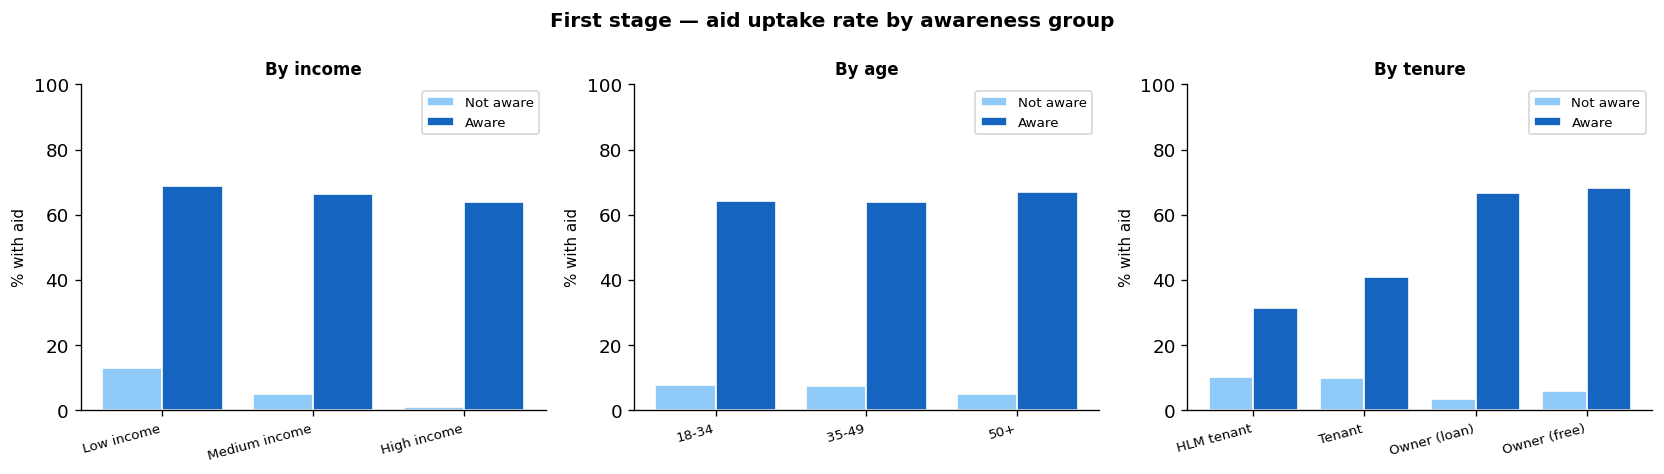

In [43]:
# first stage F-statistic plot

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = [
    ('trev', {1:'Low income', 2:'Medium income', 3:'High income'}, 'By income'),
    ('Age_rec', {1:'18-34', 2:'35-49', 3:'50+'}, 'By age'),
    ('Q100', {1:'HLM tenant', 2:'Tenant', 3:'Owner (loan)', 4:'Owner (free)'}, 'By tenure'),
]

for ax, (col, labels, title) in zip(axes, groups):
    aware_0, aware_1 = [], []
    group_names = []
    for code, label in labels.items():
        sub = df_iv[df_long[col] == code]
        if len(sub) < 20:
            continue
        w = sub['wCal']
        uptake_aware    = (sub[sub['aware_any']==1]['a_aide'] * sub[sub['aware_any']==1]['wCal']).sum() / sub[sub['aware_any']==1]['wCal'].sum() * 100
        uptake_unaware  = (sub[sub['aware_any']==0]['a_aide'] * sub[sub['aware_any']==0]['wCal']).sum() / sub[sub['aware_any']==0]['wCal'].sum() * 100 if sub[sub['aware_any']==0]['wCal'].sum() > 0 else 0
        aware_0.append(uptake_unaware)
        aware_1.append(uptake_aware)
        group_names.append(label)

    x = np.arange(len(group_names))
    ax.bar(x - 0.2, aware_0, 0.4, label='Not aware', color='#90CAF9', edgecolor='white')
    ax.bar(x + 0.2, aware_1, 0.4, label='Aware', color='#1565C0', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(group_names, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('% with aid', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 100)

fig.suptitle('First stage — aid uptake rate by awareness group', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/iv_first_stage_groups.png', bbox_inches='tight')
plt.show()

## 4.8 Interpretation  

### Instrument validity  
The instrument is very strong. With an F-statistic of 4,775, weak-instrument bias is completely ruled out. The mechanism is intuitive: households who are aware of at least one national aid are 59 percentage points more likely to actually use one (6% vs. 66% uptake). This is the largest possible first-stage bite you could hope for with a binary instrument.  

### Main result : LATE = 0.391  
The weighted 2SLS estimate tells you: among households who adopted an aid because they were made aware of it (the "compliers"), receiving that aid caused them to perform 0.39 additional energy gestures. Since the sample mean is 1.60 gestures, this represents a ~24% increase in renovation depth — a substantial additionality effect that is highly significant (p < 0.001, CI [0.276, 0.507]).
The OLS estimate (0.459) is slightly larger, confirming the expected direction of selection bias: households who actively seek out aids are also more motivated renovators, so OLS slightly inflates the true causal effect.  

### Wu-Hausman test  
The p-value of 0.174 means you cannot formally reject the null of no endogeneity at the 5% level. However, the Wu-Hausman test failing to reject does not mean OLS is unbiased, only that the bias cannot be precisely measured here. Besides, IV remains the right estimator on theoretical grounds regardless of the test outcome.  

### Policy conclusion  
The result supports genuine additionality: the French energy renovation aid system does trigger deeper renovations beyond what households would have done otherwise, at least for the population of "complier" households reached through information campaigns. A 24% increase in energy gestures among compliers is a meaningful effect, and it validates the targeting logic of outreach-based policies like local "guichets" and one-stop-shop programs.